In [1]:
import pandas as pd

df=pd.read_csv('Message_Intelligence_Dataset_5200.csv')
df.head(5)

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [2]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

Fill missing values

In [3]:
df["sender_activity_score"] = df["sender_activity_score"].fillna(df["sender_activity_score"].mean())
df["sender_account_age_days"] = df["sender_account_age_days"].fillna(df["sender_account_age_days"].median())
df["messages_sent_last_24h"] = df["messages_sent_last_24h"].fillna(df["messages_sent_last_24h"].median())

print(df.isnull().sum())

message_id                 0
message_text               0
message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
timestamp                  0
hour_of_day                0
day_of_week                0
spam_label                 0
dtype: int64


Removing outliers from numeric columns

In [4]:
num_cols=df.select_dtypes(include=['int64','float64'])
num_cols=num_cols.drop(columns=['message_id','spam_label'])
num_cols.head(5)

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week
0,99,11,1,4,0,0,1,56.6,500.0,6.0,2,0
1,73,12,0,0,0,0,0,16.6,207.0,0.0,21,2
2,67,13,0,0,0,0,1,25.7,418.0,6.0,13,5
3,64,13,0,4,0,0,1,48.8,276.0,5.0,23,2
4,84,14,0,0,0,0,1,33.0,683.0,7.0,11,5


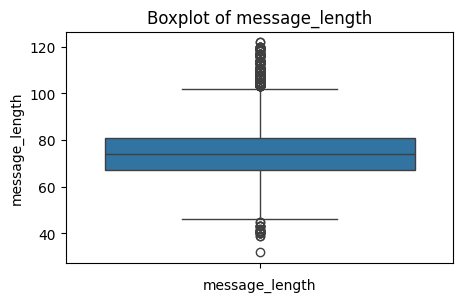

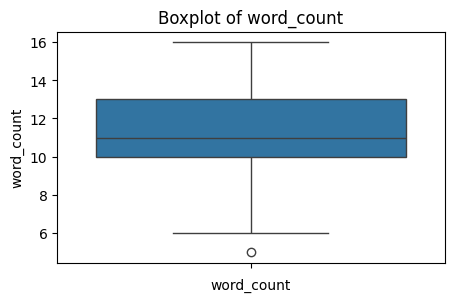

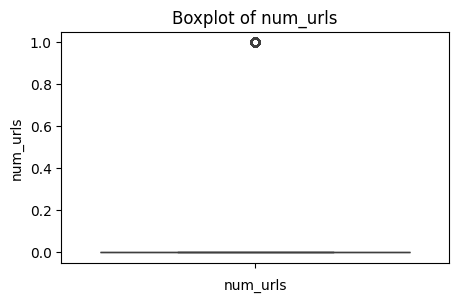

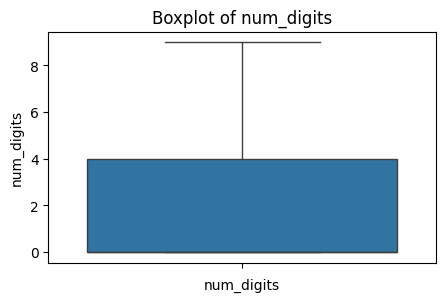

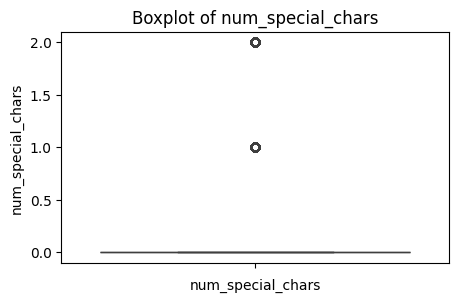

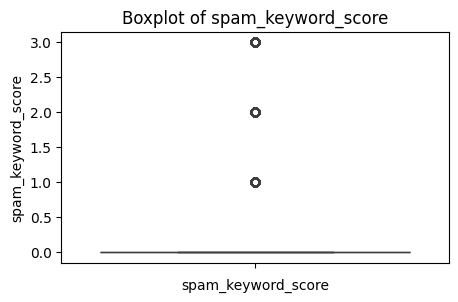

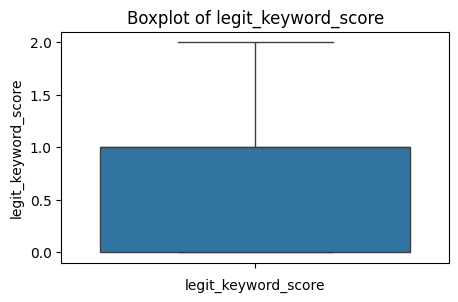

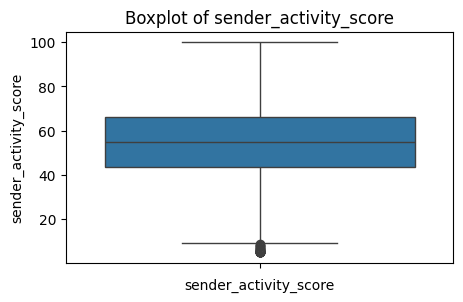

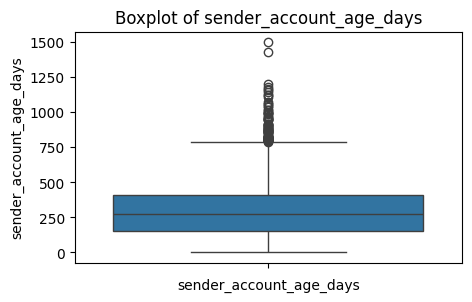

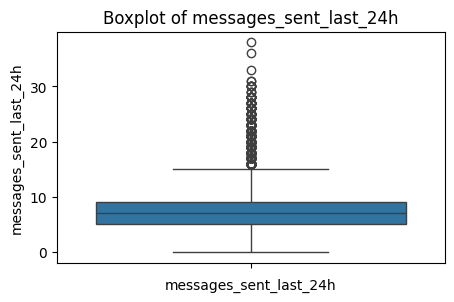

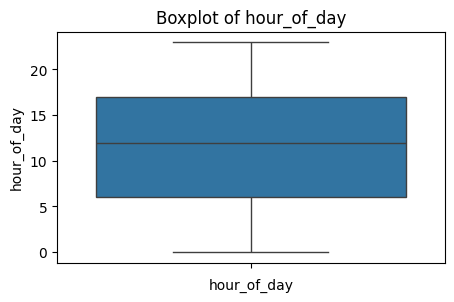

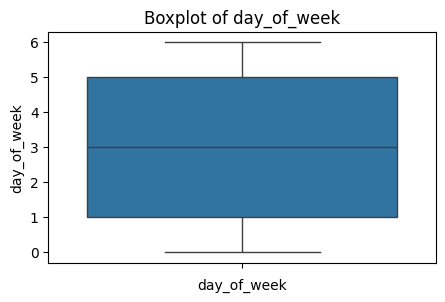

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(num_cols[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [6]:
# for col in num_cols.columns:
#     q1 = df[col].quantile(0.25)
#     q3 = df[col].quantile(0.75)
#     iqr = q3 - q1

#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr

#     df = df[(df[col] >= lower) & (df[col] <= upper)]

# print('original shape:', num_cols.shape)
# print('after removing outliers:', df.shape)

Removing outliers using winsorization

In [7]:
# df_clean[col] = df_clean[col].clip(lower, upper)

for col in num_cols.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower, upper)
    # df = df[(df[col] >= lower) & (df[col] <= upper)]

print('original shape:', num_cols.shape)
print('after removing outliers:', df[col].shape)

original shape: (5200, 12)
after removing outliers: (5200,)


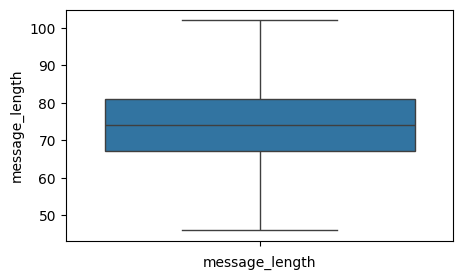

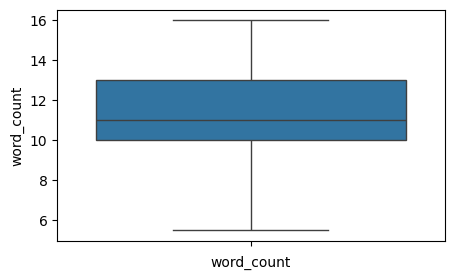

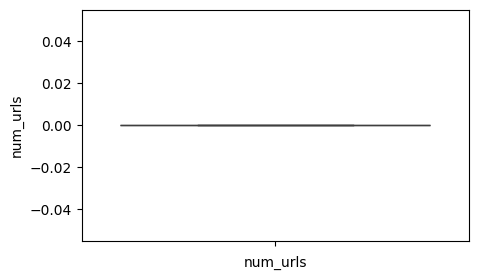

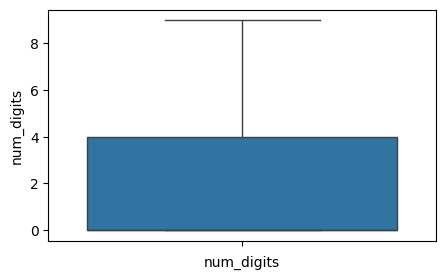

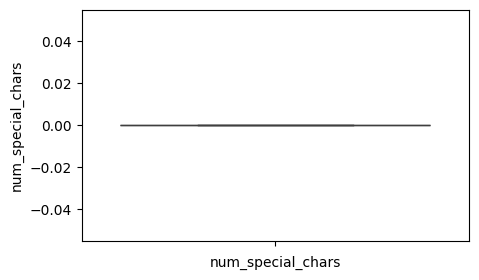

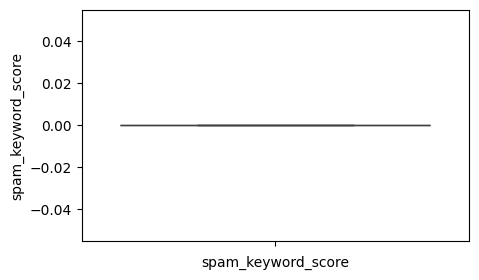

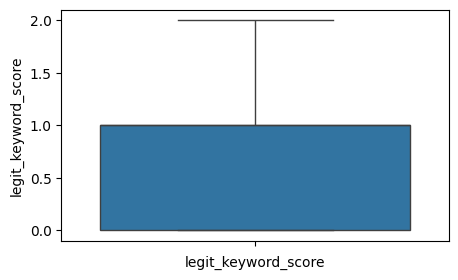

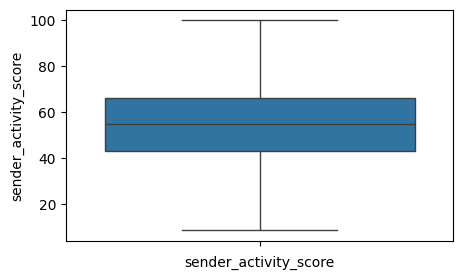

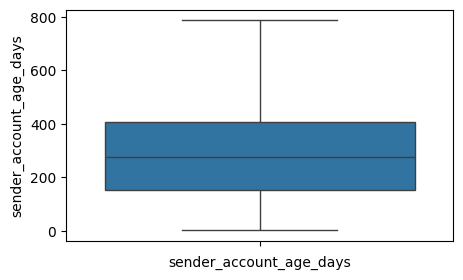

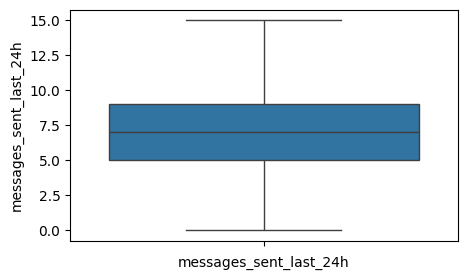

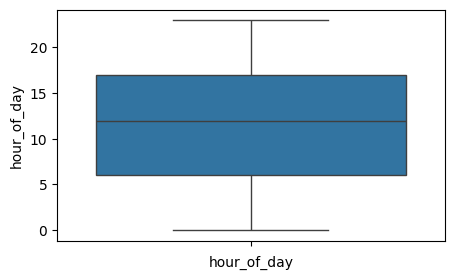

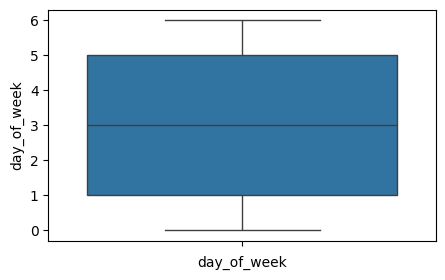

In [8]:
for col in num_cols.columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

Scaling numeric features

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numeric_cols = ['sender_activity_score','sender_account_age_days','messages_sent_last_24h','message_length','word_count']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df[numeric_cols].head(7)

,sender_activity_score,sender_account_age_days,messages_sent_last_24h,message_length,word_count
0,0.099852,1.129346,-0.401129,2.133645,-0.284361
1,-2.191182,-0.477348,-1.924218,-0.148491,0.337324
2,-1.669972,0.679691,-0.401129,-0.675138,0.959010
3,-0.346900,-0.098980,-0.654977,-0.938461,0.959010
4,-1.251858,2.132845,-0.147281,0.817028,1.580696
5,1.033449,-1.075061,1.883505,-2.342852,-2.149419
6,-1.223220,2.099943,-1.416522,0.641479,0.959010


Part C: Baseline Model - K-Nearest Neighbors

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop(columns=['message_id', 'spam_label','message_text','timestamp'])
y = df['spam_label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9836538461538461

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       845
           1       0.99      0.92      0.95       195

    accuracy                           0.98      1040
   macro avg       0.99      0.96      0.97      1040
weighted avg       0.98      0.98      0.98      1040


Confusion Matrix

[[843   2]
 [ 15 180]]


Applying different k values

In [11]:

model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f'k-value: 2, accuracy: {accuracy_score(y_test, pred)}')

model2 = KNeighborsClassifier(n_neighbors=6)
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)
print(f'k-value: 6, accuracy: {accuracy_score(y_test, pred2)}')

model3 = KNeighborsClassifier(n_neighbors=10)
model3.fit(X_train, y_train)
pred3 = model3.predict(X_test)
print(f'k-value: 10, accuracy: {accuracy_score(y_test, pred3)}')

model4 = KNeighborsClassifier(n_neighbors=15)
model4.fit(X_train, y_train)
pred4 = model4.predict(X_test)
print(f'k-value: 15, accuracy: {accuracy_score(y_test, pred4)}')

k-value: 2, accuracy: 0.9788461538461538
k-value: 6, accuracy: 0.9807692307692307
k-value: 10, accuracy: 0.9798076923076923
k-value: 15, accuracy: 0.9788461538461538


Distance metrics

In [12]:
metrics = ['euclidean', 'manhattan', 'minkowski']

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5,metric=metric)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)

    print(f"\nDistance Metric: {metric}")
    print("Accuracy:", accuracy_score(y_test, pred))


Distance Metric: euclidean
Accuracy: 0.9836538461538461

Distance Metric: manhattan
Accuracy: 0.989423076923077

Distance Metric: minkowski
Accuracy: 0.9836538461538461


Part D: Support Vector Machine Classifier

* linear

In [13]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_linear))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_linear))

Linear Kernel Accuracy: 0.9923076923076923

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       845
           1       0.97      0.98      0.98       195

    accuracy                           0.99      1040
   macro avg       0.99      0.99      0.99      1040
weighted avg       0.99      0.99      0.99      1040


Confusion Matrix

[[840   5]
 [  3 192]]


* rbf

In [14]:
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rbf))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_rbf))

RBF Kernel Accuracy: 0.9875

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       845
           1       0.99      0.94      0.97       195

    accuracy                           0.99      1040
   macro avg       0.99      0.97      0.98      1040
weighted avg       0.99      0.99      0.99      1040


Confusion Matrix

[[843   2]
 [ 11 184]]


* Analyze Margin Separation and Support Vectors

In [15]:
print("Support vectors for each class:")
print(svm_linear.n_support_)

print("\nTotal Support Vectors:")
print(sum(svm_linear.n_support_))

Support vectors for each class:
[36 35]

Total Support Vectors:
71


Shape

In [16]:
print(svm_linear.support_vectors_.shape)

(71, 12)


* Compare SVM Performance with KNN

In [20]:
from sklearn.metrics import accuracy_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        'KNN',
        'SVM (Linear)',
        'SVM (RBF)'
    ],"Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf)
    ]
})
print(comparison)

          Model  Accuracy
0           KNN  0.983654
1  SVM (Linear)  0.992308
2     SVM (RBF)  0.987500


Part E: Naive Bayes Classifier & Probability

In [21]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_nb))
print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_nb))

Accuracy: 0.989423076923077

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       845
           1       0.95      0.99      0.97       195

    accuracy                           0.99      1040
   macro avg       0.97      0.99      0.98      1040
weighted avg       0.99      0.99      0.99      1040


Confusion Matrix
[[835  10]
 [  1 194]]


Manual calculation

In [32]:
sample = X_test.iloc[[1]]
print(sample)

print("Model Prediction:", nb.predict(sample))
print(nb.predict_proba(sample))

     message_length  word_count  num_urls  num_digits  num_special_chars  \
655        -1.11401   -0.284361         0           0                  0   

     spam_keyword_score  legit_keyword_score  sender_activity_score  \
655                   0                    0              -0.799379   

     sender_account_age_days  messages_sent_last_24h  hour_of_day  day_of_week  
655                -1.541167                1.883505           11            6  
Model Prediction: [1]
[[6.26461494e-08 9.99999937e-01]]


Part F: Model Comparison & Evaluation

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["KNN", "SVM (Linear)", "SVM (RBF)", "Naive Bayes"],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_nb)
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_rbf),
        precision_score(y_test, y_pred_nb)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_rbf),
        recall_score(y_test, y_pred_nb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rbf),
        f1_score(y_test, y_pred_nb)
    ]
})

print(results)

          Model  Accuracy  Precision    Recall  F1 Score
0           KNN  0.983654   0.989011  0.923077  0.954907
1  SVM (Linear)  0.992308   0.974619  0.984615  0.979592
2     SVM (RBF)  0.987500   0.989247  0.943590  0.965879
3   Naive Bayes  0.989423   0.950980  0.994872  0.972431


* Identify Best Model

Highest Accuracy

In [37]:
best_accuracy = results.loc[
    results["Accuracy"].idxmax()
]

print("Highest Accuracy")
print(best_accuracy)

Highest Accuracy
Model        SVM (Linear)
Accuracy         0.992308
Precision        0.974619
Recall           0.984615
F1 Score         0.979592
Name: 1, dtype: object


Highest Precision

In [39]:
best_precision = results.loc[
    results["Precision"].idxmax()
]

print("Highest Precision")
print(best_precision)

Highest Precision
Model        SVM (RBF)
Accuracy        0.9875
Precision     0.989247
Recall         0.94359
F1 Score      0.965879
Name: 2, dtype: object


Highest recall

In [41]:
best_precision = results.loc[
    results["Recall"].idxmax()
]

print("Highest Recall")
print(best_precision)

Highest Recall
Model        Naive Bayes
Accuracy        0.989423
Precision        0.95098
Recall          0.994872
F1 Score        0.972431
Name: 3, dtype: object


Summary

In [42]:
summary = pd.DataFrame({
    "Metric": [
        "Highest Accuracy",
        "Highest Precision",
        "Highest Recall",
        "Highest F1 Score"
    ],

    "Best Model": [
        results.loc[results["Accuracy"].idxmax(), "Model"],
        results.loc[results["Precision"].idxmax(), "Model"],
        results.loc[results["Recall"].idxmax(), "Model"],
        results.loc[results["F1 Score"].idxmax(), "Model"]
    ]
})

print(summary)

              Metric    Best Model
0   Highest Accuracy  SVM (Linear)
1  Highest Precision     SVM (RBF)
2     Highest Recall   Naive Bayes
3   Highest F1 Score  SVM (Linear)
